In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# os.environ["JAX_PLATFORM_NAME"] = "cpu"

In [3]:
import h5py, os, tqdm, glob, scipy
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import jax
import jax.numpy as jnp
import jax_cosmo as jc

import optax
from flax import nnx
import orbax.checkpoint as ocp
import jraph

import diffrax
from diffrax import diffeqsolve, ODETerm, Dopri5, LeapfrogMidpoint, PIDController, SaveAt, ConstantStepSize
from jax.experimental.ode import odeint

import jaxpm
from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.pm import linear_field, lpt, make_ode_fn, pm_forces, make_ode_fn_diffrax, make_ode_fn
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.utils import power_spectrum, cross_correlation_coefficients
from jaxpm.nn import MLP, ResNet3D, ResNetBlock3D, GraphConvolution, CNN, HybridNet, AttentionGNN
from jaxpm import camels, plotting, hpm, nn, graph, pm

print(jax.devices("gpu"))
print(jax.default_backend())

[cuda(id=0)]
gpu


# configuration

In [4]:
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3
box_size = 25.0

# CAMELS

In [5]:
i_snapshots=range(1, 33+8, 8)

CAMELS = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims"
# CODE = "IllustrisTNG"
CODE = "SIMBA"
# CODE = "Astrid"
SIMSET = "CV"
CV = "CV_0"

nbody_dict = camels.load_CV_snapshots(
    os.path.join(CAMELS, CODE + "_DM", SIMSET, CV),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=False
)

hydro_dict = camels.load_CV_snapshots(
    os.path.join(CAMELS, CODE, SIMSET, CV),
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA_DM/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA_DM/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA_DM/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA_DM/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA_DM/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 5/5 [00:14<00:00,  2.92s/it]


Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_018.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_042.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_058.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_074.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/SIMBA/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


finding unique gas particle indices:  20%|██        | 1/5 [00:01<00:05,  1.35s/it]

Found 368 duplicate gas particle IDs


...

finding unique gas particle indices:  80%|████████  | 4/5 [00:18<00:05,  5.03s/it]

Found 14787 duplicate gas particle IDs


finding unique gas particle indices: 100%|██████████| 5/5 [00:23<00:00,  4.77s/it]


There are 15915410 (94.86%) gas particles that exist in all snapshots


loading snapshots: 100%|██████████| 5/5 [00:56<00:00, 11.38s/it]


In [6]:
@nnx.jit(static_argnames=("loss_fn",))
def train_step(model, optimizer, loss_fn):
    loss, grads = nnx.value_and_grad(loss_fn)(model)
    optimizer.update(grads)

    return loss

losses = []

In [7]:
cosmo = hydro_dict["cosmo"]
scales = hydro_dict["scales"]

dm_poss = hydro_dict["dm_poss"]
dm_vels = hydro_dict["dm_vels"]

gas_poss = hydro_dict["gas_poss"]
gas_vels = hydro_dict["gas_vels"]

edges = graph.get_edges(gas_poss, scales, k=4)

# latent_init = cic_read(cic_paint(jnp.zeros(mesh_shape), gas_poss[0]), gas_poss[0])
# latent_init = jnp.expand_dims(latent_init, axis=-1)

# latent_init = jnp.ones((parts_per_dim**3,1)))

latent_init = None

def solve_ode_diffrax(model, architecture):
    res = diffeqsolve(
            terms=ODETerm(hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, integrator_type="diffrax", architecture=architecture, precomputed_edges=edges)),
            solver=LeapfrogMidpoint(),
            t0=scales[0],
            t1=scales[-1],
            dt0=0.02,
            y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
            saveat=SaveAt(ts=scales),
            max_steps=100,
            stepsize_controller=ConstantStepSize(),
        )

    res = res.ys

    return res

In [8]:
vcic_paint = jax.vmap(cic_paint, in_axes=(None,0,None))
vcic_read = jax.vmap(cic_read, in_axes=(0,0))

vpower_spectrum = jax.vmap(
    lambda fields: 
        power_spectrum(
            compensate_cic(fields),
            boxsize=np.array([box_size] * 3),
            kmin=np.pi / box_size,
            dk=2 * np.pi / box_size,
        )
)

# vcross_correlation_separate = jax.vmap(
#     lambda field_a, field_b:
#         cross_correlation_coefficients(
#             compensate_cic(field_a),
#             compensate_cic(field_b),
#             boxsize=np.array([box_size] * 3),
#             kmin=np.pi / box_size,
#             dk=2 * np.pi / box_size,
#         )
# )


# loss

### CAMELS ground truth

In [9]:
gas_mass = cosmo.Omega_b / (cosmo.Omega_c + cosmo.Omega_b)
dm_mass = cosmo.Omega_c / (cosmo.Omega_c + cosmo.Omega_b)

# per-particle reference
ref_gas_pos = jnp.stack(gas_poss, axis=0)
ref_gas_vel = jnp.stack(gas_vels, axis=0)

# field-level reference
n_rho_dm = vcic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"], 1)
# n_rho_tot = n_rho_dm

h_rho_dm = vcic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"], dm_mass)
h_rho_gas = vcic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"], gas_mass)
# h_rho_tot = h_rho_dm + h_rho_gas

# power spectrum reference
_, n_cl_dm = vpower_spectrum(n_rho_dm)

_, h_cl_dm = vpower_spectrum(h_rho_dm)
_, h_cl_gas = vpower_spectrum(h_rho_gas)

# vcross_correlation = lambda rhos: vcross_correlation_separate(rhos, ref_rho)

In [10]:
pm_ode = pm.make_ode_fn_diffrax(cosmo, mesh_shape)

pm_res = diffeqsolve(
        terms=ODETerm(pm_ode),
        solver=LeapfrogMidpoint(),
        t0=nbody_dict["scales"][0],
        t1=nbody_dict["scales"][-1],
        dt0=0.02,
        y0=jnp.stack([nbody_dict["dm_poss"][0], nbody_dict["dm_vels"][0]]),
        saveat=SaveAt(ts=nbody_dict["scales"]),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)
pm_res = pm_res.ys
pm_res = jnp.transpose(pm_res, (1,0,2,3))

pm_dm_poss, pm_dm_vels = pm_res

pm_rho_dm = vcic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"], 1)
_, pm_cl_dm = vpower_spectrum(pm_rho_dm)

In [11]:
# pm_ode = hpm.get_hpm_network_ode_fn(None, mesh_shape, cosmo, "diffrax", gravity_only=True)

# pm_res = diffeqsolve(
#         terms=ODETerm(pm_ode),
#         solver=LeapfrogMidpoint(),
#         t0=scales[0],
#         t1=scales[-1],
#         dt0=0.02,
#         y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
#         saveat=SaveAt(ts=scales),
#         max_steps=100,
#         stepsize_controller=ConstantStepSize(),
# )

# pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels, _ = pm_res.ys

# pm_rho_dm = vcic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"], 1)

# pm_rho_dm = vcic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"], dm_mass)
# pm_rho_gas = vcic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"], gas_mass)


# # pm_rho_dm = vcic_paint(jnp.zeros(mesh_shape), pm_dm_poss, dm_mass)
# # pm_rho_gas = vcic_paint(jnp.zeros(mesh_shape), pm_gas_poss, gas_mass)
# # pm_rho_tot = pm_rho_dm + pm_rho_gas

# # _, pm_cl_dm = vpower_spectrum(pm_dm_rho)
# # _, pm_cl_gas = vpower_spectrum(pm_gas_rho)
# # _, pm_cl_tot = vpower_spectrum(pm_rho_tot)

### particle-level

In [50]:
# def particle_loss_fn(model, architecture):
#     res = solve_ode_diffrax(model, architecture)
#     # res = solve_ode_diffrax(model)

#     # pos_loss = jnp.sum((res[2] - ref_pos)**2, axis=-1)
#     pos_loss = jnp.sum((res[2]%64 - ref_gas_pos)**2, axis=-1)

#     pos_loss = jnp.where(pos_loss < mesh_per_dim//2, pos_loss, 0.)
#     # pos_loss *= jnp.expand_dims(scales, axis=1)
#     pos_loss = jnp.mean(pos_loss)

#     # vel_loss = jnp.sum((res[3] - ref_gas_vel)**2, axis=-1)
#     # vel_loss = jnp.where(vel_loss < mesh_per_dim//2, vel_loss, 0.)
#     # # vel_loss *= jnp.expand_dims(scales, axis=1)
#     # vel_loss = jnp.mean(vel_loss)

#     # res_rho = vcic_paint(jnp.zeros(mesh_shape), res[2], cosmo.Omega_b / cosmo.Omega_c)
#     # _, res_cls = vpower_spectrum(res_rho)
#     # cl_loss = jnp.mean(jnp.sum((res_cls/h_cl_gas - 1)**2, axis=-1))

#     # _, res_cross = vcross_correlation(res_rho)
#     # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))

#     # return pos_loss + 0.01 * vel_loss + 0.01 * cl_loss
#     return pos_loss


In [65]:
def particle_loss_fn(model, architecture):
    dm_poss, dm_vels, gas_poss, gas_vels, _ = solve_ode_diffrax(model, architecture)

    delta_pos = ((gas_poss - ref_gas_pos + mesh_per_dim // 2) % mesh_per_dim) - mesh_per_dim // 2
    pos_loss = jnp.sum(delta_pos**2, axis=-1)
    pos_loss = jnp.mean(pos_loss)

    vel_disp = jnp.std(gas_vels, axis=0)
    vel_loss = jnp.sum(((gas_vels - ref_gas_vel) / (vel_disp + 1e-5))**2, axis=-1)
    vel_loss = jnp.mean(vel_loss)

    res_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)
    _, res_cls = vpower_spectrum(res_rho)
    cl_loss = jnp.mean(jnp.sum((res_cls/h_cl_gas - 1)**2, axis=-1))

    # _, res_cross = vcross_correlation(res_rho)
    # cross_loss = jnp.mean(jnp.sum((res_cross/jnp.sqrt(ref_cls * res_cls) - 1)**2, axis=-1))

    # return pos_loss + 0.01 * vel_loss + 0.01 * cl_loss
    return pos_loss
    # return cl_loss


In [66]:
# def particle_loss_fn(model, architecture):
#     dm_poss, dm_vels, gas_poss, gas_vels, _ = solve_ode_diffrax(model, architecture)

#     res_rho_dm = vcic_paint(jnp.zeros(mesh_shape), dm_poss, dm_mass)
#     res_rho_gas = vcic_paint(jnp.zeros(mesh_shape), gas_poss, gas_mass)

#     _, res_cl_dm = vpower_spectrum(res_rho_dm)
#     _, res_cl_gas = vpower_spectrum(res_rho_gas)    

#     camels_cl_tot_ratio = (h_cl_dm + h_cl_gas) / n_cl_dm
#     pm_cl_tot_ratio = (res_cl_dm + res_cl_gas) / pm_cl_dm
#     cl_loss = pm_cl_tot_ratio / camels_cl_tot_ratio - 1
        
#     cl_loss = jnp.sum(cl_loss**2, axis=-1)
#     cl_loss = jnp.mean(cl_loss)

#     return cl_loss


### field-level

In [67]:
def field_loss_fn(model, architecture):
    pass

# architecture

### MLP

In [68]:
# with_latent = False

# model = MLP(
#     d_in=5 + with_latent, 
#     # d_in=3 + with_latent,
#     d_out=1 + with_latent, 
#     d_hidden=64, 
#     n_hidden=4, 
#     rngs=nnx.Rngs(0)
# )
# architecture = "mlp"

### MLP + CNN

In [82]:
with_latent = False

mlp = MLP(
    d_in=5 + with_latent,
    d_out=8, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

cnn = CNN(
    d_in=4 + with_latent,
    d_out=8,
    d_hidden=8,
    n_hidden=2,
    kernel_size=(3, 3, 3),
    strides=1,
    rngs=nnx.Rngs(0)
)

model = HybridNet(
    mlp,
    cnn,
    d_out=1 + with_latent,
    rngs=nnx.Rngs(0)
)

architecture = "mlp+cnn"

### GNN

on the fly

In [83]:
# with_latent = False

# model = AttentionGNN(
#     d_node=5 + with_latent,
#     d_edge=1,
#     d_query=16,
#     n_hidden=4,
#     d_out=1 + with_latent,
#     rngs=nnx.Rngs(0),
# )

# architecture = "gnn"

# training

In [84]:
total_steps = 300
learning_rate = 1e-4
# learning_rate = optax.cosine_decay_schedule(
#     init_value=1e-3, 
#     decay_steps=total_steps, 
#     alpha=0.1
# )
clip_norm = 1

optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(clip_norm),
        optax.adam(learning_rate)
    )
)

losses = []
loss_fn = lambda model: particle_loss_fn(model, architecture)
# loss_fn = lambda model: field_loss_fn(model, architecture)

  0%|          | 0/300 [00:00<?, ?it/s]

No latent variable
No latent variable
No latent variable


Loss: 167.2383: 100%|██████████| 300/300 [04:38<00:00,  1.08it/s]


[None]

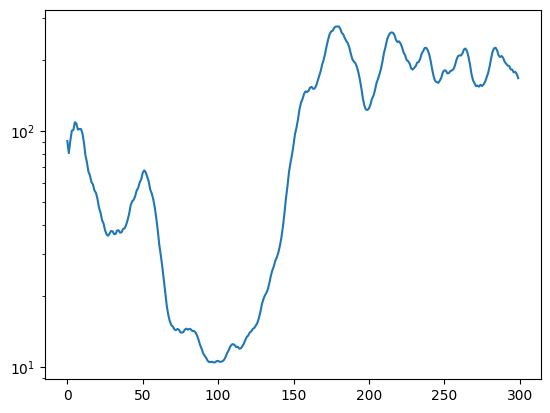

In [85]:
for i in (pbar := tqdm.tqdm(range(total_steps))):  
    loss = train_step(model, optimizer, loss_fn)

    losses.append(loss)
    pbar.set_description(f"Loss: {loss:.4f}")

fig, ax = plt.subplots()
ax.plot(losses)
ax.set(yscale="log")

### checkpointing

In [86]:
# # see https://flax.readthedocs.io/en/latest/guides/checkpointing.html
# # checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_sim.jx")
# checkpoint_file = os.path.join(os.getcwd(), "checkpoints/hpm_mlp_sim_new_2.jx")
# checkpointer = ocp.StandardCheckpointer()
# print(os.getcwd())

In [87]:
# _, params = nnx.split(model)
# checkpointer.save(checkpoint_file, params, force=True)

In [88]:
# abstract_model = nnx.eval_shape(lambda: model)
# graphdef, abstract_params = nnx.split(abstract_model)

# params = checkpointer.restore(checkpoint_file, abstract_params)
# model = nnx.merge(graphdef, params)

# run the simulation

In [89]:
pm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, architecture="mlp", gravity_only=True, integrator_type="diffrax")

pm_res = diffeqsolve(
        terms=ODETerm(pm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels, pm_gas_latents = pm_res.ys

In [90]:
hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, architecture="mlp", gravity_only=False, integrator_type="diffrax")

hpm_res = diffeqsolve(
        terms=ODETerm(hpm_ode),
        solver=LeapfrogMidpoint(),
        t0=scales[0],
        t1=scales[-1],
        dt0=0.01,
        y0=(dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0], latent_init),
        saveat=SaveAt(ts=scales),
        max_steps=100,
        stepsize_controller=ConstantStepSize(),
)

hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels, hpm_gas_latents = hpm_res.ys

TypeError: HybridNet.__call__() missing 2 required positional arguments: 'particle' and 'field'

In [ ]:
plotting.compare_particle_evolution(
    mesh_shape, 
    scales, 
    jnp.stack([gas_poss, pm_gas_poss, hpm_gas_poss], axis=0), 
    title="gas",
    col_titles=["CAMELS", "gravity", "gravity + pressure"],
    include_pk=True,
    include_reference=True,
)